# 02 · Alias-name Coverage

**Purpose.** Quantify how much GenBank gene-name variation is resolved by the per-virus alias maps *before* any coordinate lifting. Reproduces `alias_summary_overall.tsv` / `alias_coverage.png`.

## Inputs

Query datasets for FMD/PRRS/PED; alias maps via `load_reference_bundle`.

In [1]:
from pathlib import Path
import sys, time

import pandas as pd
import matplotlib.pyplot as plt

# --- anchor ROOT to the repo (folder that contains app/src) ---
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "app" / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA   = ROOT / "app" / "data"
CONFIG = ROOT / "app" / "config"

# References (verify these are the intended ref records for the paper):
FMD_REF    = DATA / "FMD"  / "FMD_ref_test.gb"        # alt: FMD_FJ175661_Anno.gb
FMD_QUERY  = DATA / "FMD"  / "FMD_100seq_anno.gb"
PRRS_REF   = DATA / "PRRS" / "PRRS_ref_test.gb"       # alt: PRRS_MT746146_Anno.gb
PRRS_QUERY = DATA / "PRRS" / "PRRS_100seq_anno.gb"
PED_REFS   = {"ref_1": DATA / "PED" / "PED_ref_1.gb",
              "ref_2": DATA / "PED" / "PED_ref_2.gb"}
PED_QUERY  = DATA / "PED" / "PED_100seqs.gb"

# Run toggle: keep False for a fast smoke test, True for the full 100-record run.
RUN_FULL = False
SAMPLE_N = 10


In [2]:
# outputs land inside this unit folder so figures/tables sit next to the notebook
UNIT_DIR = ROOT / "app" / "validation" / "01_alias_coverage"
OUT = UNIT_DIR / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
print("outputs ->", OUT)

outputs -> /Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/validation/01_alias_coverage/outputs


## Run — collect and resolve alias rows (real module)

In [3]:
from app.src.io.genbank_parser import load_genbank_records
from app.validation._shared.validation_utils import (
    collect_alias_rows, evaluate_alias_rows, load_reference_bundle,
)

DATASETS = {"fmd": (FMD_REF, FMD_QUERY),
            "prrs": (PRRS_REF, PRRS_QUERY),
            "ped": (PED_REFS["ref_1"], PED_QUERY)}

evaluated = []
for label, (ref, query) in DATASETS.items():
    bundle = load_reference_bundle(ref)
    records = load_genbank_records(query)
    rows = collect_alias_rows(records)                    # every qualifier value seen
    ev = evaluate_alias_rows(rows, bundle["alias_lookup"], label)
    evaluated.append(ev)
alias_all = pd.concat(evaluated, ignore_index=True)
alias_all.head()

,virus,record_id,feature_type,field,raw_value,resolved_to,is_canonical
0,fmd,AY686687.1,CDS,product,polyprotein,excluded,False
1,fmd,AY687333.1,CDS,product,polyprotein,excluded,False
2,fmd,AY687333.1,mat_peptide,product,L-protease,Lpro,True
3,fmd,AY687333.1,mat_peptide,product,VP4,VP4,True
4,fmd,AY687333.1,mat_peptide,product,VP2,VP2,True


## Metrics

Share of raw names resolved to canonical vs unresolved vs excluded, per virus and per field.

In [4]:
overall = (alias_all.assign(status=lambda d: d["resolved_to"].where(
                 d["resolved_to"].isin(["unresolved", "excluded"]), "canonical"))
           .groupby(["virus", "status"]).size().reset_index(name="n"))
overall_pivot = overall.pivot_table(index="virus", columns="status", values="n", fill_value=0)
overall_pivot["canonical_pct"] = (overall_pivot.get("canonical", 0) /
                                   overall_pivot.sum(axis=1) * 100).round(2)
overall_pivot.to_csv(OUT / "alias_summary_overall.tsv", sep="\t")
overall_pivot

status,canonical,excluded,unresolved,canonical_pct
virus,,,,
fmd,1178.0,100.0,0.0,92.18
ped,1051.0,65.0,0.0,94.18
prrs,1611.0,145.0,3.0,91.59


## Figure

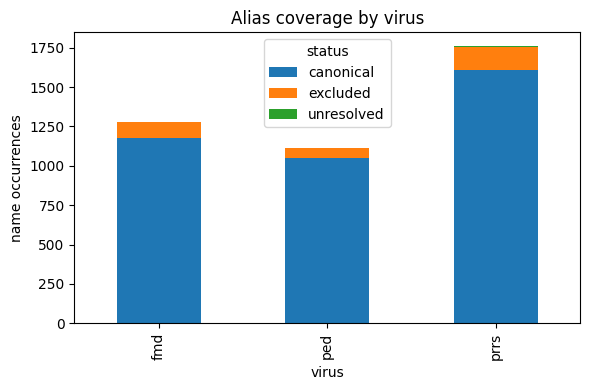

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
overall_pivot.drop(columns=["canonical_pct"], errors="ignore").plot.bar(stacked=True, ax=ax)
ax.set_ylabel("name occurrences"); ax.set_title("Alias coverage by virus")
fig.tight_layout(); fig.savefig(OUT / "alias_coverage.png", dpi=200)

## Interpretation

> ⚠️ **TODO**: phần lớn biến thể tên đã resolve tự động; các tên còn unresolved là ứng viên cho human/LLM review (nối sang unit 07).